# Homework 10: RLHF on Congressional Speeches

Refer to the corresponding lab.

Remember that these homeworks work as a completion grade. **You can skip one section.**

---

## Overview

In this homework we will build a minimal but real RLHF pipeline applied to **US congressional floor speeches**.

The goal: use reinforcement learning to guide GPT-2 to generate text that sounds more like **Republican** speeches when given a Democratic speech as a prompt.

The pipeline has three stages — the same three stages from the lab:

1. **Reward Model** — a DistilBERT classifier trained to distinguish Republican from Democratic speeches
2. **GRPO Training** — use the reward model's score as a signal to fine-tune GPT-2
3. **Evaluation** — compare generated text before and after GRPO training

The reward model code is provided. The TODOs are in the GRPO section.

In [2]:
!pip install -q transformers datasets trl peft accelerate
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.0 MB/s eta 0:00:00
Dependencies installed.


In [3]:
import warnings; warnings.simplefilter('ignore')
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer, DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TextClassificationPipeline
)
from trl import GRPOTrainer, GRPOConfig
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---
## Part 1 — Load the Congressional Speeches Dataset

We use the congressional speeches dataset from the course. Each speech has a `party` label (Democrat / Republican) which we will use to train the reward model.

In [5]:
# Load congressional speeches
# Upload us_congress_speeches_sample.csv from the course GitHub if needed
from google.colab import files
uploaded = files.upload()

Saving us_congress_speeches_sample.csv to us_congress_speeches_sample.csv


In [6]:
df = pd.read_csv('us_congress_speeches_sample.csv')
df['year'] = pd.to_datetime(df['date']).dt.year
df['republican'] = (df['party'] == 'Republican').astype(int)

print(f'Total speeches: {len(df):,}')
print(f'Republican: {df["republican"].sum():,} | Democrat: {(df["republican"]==0).sum():,}')
df[['date', 'party', 'republican', 'text']].head(3)

Total speeches: 28,731
Republican: 13,480 | Democrat: 15,251


,date,party,republican,text
0,2003-06-10,Democrat,0,"Mr. ISRAEL. Mr. Speaker, I rise today to com..."
1,2012-05-08,Democrat,0,"Mr. LANGEVIN. Mr. Speaker, Democrats are com..."
2,2010-03-25,Republican,1,"Mr. BISHOP of Utah. Mr. Speaker, Lori Garver..."


---
## Part 2 — Train the Reward Model

We fine-tune **DistilBERT** to classify speeches as Republican (1) or Democrat (0). This classifier will serve as our reward model during GRPO training: speeches that score higher on the Republican class get higher reward.

This section is provided — read through it to understand what the reward model is doing before moving to the TODO section.

In [7]:
# ── Prepare data ─────────────────────────────────────────────────────────
# Use a manageable subset — 800 speeches total (you can increase it if you have high computing power)
df_sample = df.dropna(subset=['text']).sample(4000, random_state=42).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    df_sample['text'].tolist(),
    df_sample['republican'].tolist(),
    test_size=0.2, random_state=42,
    stratify=df_sample['republican']
)

print(f'Train: {len(X_train)} speeches | Test: {len(X_test)} speeches')
print(f'Train Republican rate: {sum(y_train)/len(y_train):.2f}')

Train: 3200 speeches | Test: 800 speeches
Train Republican rate: 0.48


In [8]:
# ── Fine-tune DistilBERT as the reward model ─────────────────────────────
model_name    = 'distilbert-base-uncased'
reward_model  = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)
distil_tok    = DistilBertTokenizerFast.from_pretrained(model_name)
reward_model.to(device)

optimizer = torch.optim.Adam([
    {'params': reward_model.distilbert.parameters(), 'lr': 1e-5},
    {'params': reward_model.classifier.parameters(), 'lr': 1e-3}
])

# Batch the training data
BATCH_SIZE = 8
X_batches = [X_train[i:i+BATCH_SIZE] for i in range(0, len(X_train), BATCH_SIZE)]
y_batches = [y_train[i:i+BATCH_SIZE] for i in range(0, len(y_train), BATCH_SIZE)]

NUM_EPOCHS = 3   # increase for better accuracy; 3 is enough for a usable reward signal
for epoch in range(NUM_EPOCHS):
    reward_model.train()
    epoch_loss = 0
    for texts, labels in tqdm(zip(X_batches, y_batches), total=len(X_batches),
                               desc=f'Epoch {epoch+1}/{NUM_EPOCHS}'):
        inputs = distil_tok(texts, return_tensors='pt', padding=True,
                             truncation=True, max_length=256)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labs   = torch.tensor(labels).long().to(device)
        output = reward_model(**inputs, labels=labs)
        output.loss.backward()
        optimizer.step(); optimizer.zero_grad()
        epoch_loss += output.loss.item()
    print(f'  Loss: {epoch_loss/len(X_batches):.4f}')

print('Reward model trained.')
torch.save(reward_model.state_dict(), 'republican_classifier.pt')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

  Loss: 0.6631


Epoch 2/3: 100%|██████████| 400/400 [01:22<00:00,  4.86it/s]


  Loss: 0.3409


Epoch 3/3: 100%|██████████| 400/400 [01:23<00:00,  4.81it/s]


  Loss: 0.1533
Reward model trained.


In [9]:
# ── Evaluate the reward model ─────────────────────────────────────────────
reward_model.eval()
correct = 0
X_test_batches = [X_test[i:i+8] for i in range(0, len(X_test), 8)]
y_test_batches = [y_test[i:i+8] for i in range(0, len(y_test), 8)]

with torch.no_grad():
    for texts, labels in zip(X_test_batches, y_test_batches):
        inputs = distil_tok(texts, return_tensors='pt', padding=True,
                             truncation=True, max_length=256)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        preds  = reward_model(**inputs).logits.argmax(dim=-1).cpu().tolist()
        correct += sum(p == l for p, l in zip(preds, labels))

print(f'Test accuracy: {correct/len(y_test)*100:.1f}%')
print('Accuracy > 60% is sufficient for a usable reward signal.')

Test accuracy: 92.4%
Accuracy > 60% is sufficient for a usable reward signal.


In [10]:
# TODO ── Wrap in a pipeline for easy scoring ──────────────────────────────────
# This pipeline takes a text and returns scores for [Democrat, Republican]
reward_pipe = TextClassificationPipeline(
    model=reward_model,      # the DistilBERT classifier we just fine-tuned
    tokenizer=distil_tok,    # its matching tokenizer (handles padding/truncation)
    device=device,           # run on the same device (GPU on the T4) as the model
    top_k=None,              # return a score for BOTH labels (return_all_scores is deprecated)
)

# function_to_apply='none' → use the raw logit as the score (higher = more Republican)
sent_kwargs = {'function_to_apply': 'none', 'batch_size': 8,
               'truncation': True, 'max_length': 256}

def get_republican_score(result):
    """Pull the LABEL_1 (Republican) score out of one pipeline result.
    Different transformers versions return either a list of dicts or a
    list-of-lists, so we normalise the shape before searching for LABEL_1."""
    # If nested (list of list of dicts), unwrap the outer list
    if isinstance(result, list) and result and isinstance(result[0], list):
        result = result[0]
    # If a single dict slipped through, wrap it in a list
    if isinstance(result, dict):
        result = [result]
    # result is now a flat list of {'label': .., 'score': ..} dicts
    return float(next(d['score'] for d in result if d['label'] == 'LABEL_1'))


# TODO Test it on these texts

test_rep = 'We must cut taxes and reduce government spending to grow the economy.'
test_dem = 'We need to invest in healthcare and protect working families from corporate greed.'

for label, text in [('Republican-sounding', test_rep), ('Democrat-sounding', test_dem)]:
    out = reward_pipe(text, **sent_kwargs)   # score this single text
    # LABEL_1 corresponds to the Republican class (label 1 in the reward model)
    rep_score = get_republican_score(out)
    print(f'{label}: Republican score = {rep_score:+.3f}')

Republican-sounding: Republican score = -0.571
Democrat-sounding: Republican score = -0.793


---
## Part 3 — GRPO Training (TODOs)

Now we use the reward model to guide GPT-2 with GRPO. The setup mirrors exactly what we did in the lab, but the reward signal is now **political framing** rather than movie sentiment.

**The idea:** start with Democratic speech fragments as prompts, ask GPT-2 to continue them, score the continuation with the Republican classifier, and use that score as the reward. After enough training steps, GPT-2 should learn to shift its continuations toward Republican-sounding language.

Complete the three TODO cells below.

### TODO 1 — Prepare the prompt dataset

We need a dataset of **Democratic speech fragments** to use as prompts. GRPO will ask GPT-2 to continue each prompt, then score the completion.

The dataset must have a `prompt` column containing short text snippets (10–40 words each) from Democratic speeches.

In [11]:
# TODO 1: Build a prompt dataset from Democratic speeches
# Steps:
#   1. Filter df to Democrat speeches only
#   2. Sample 300 speeches
#   3. Take the first 40 words of each speech as the prompt
#   4. Store in a HuggingFace Dataset with a 'prompt' column
#
# Hint: from datasets import Dataset
#       Dataset.from_dict({'prompt': [list of strings]})

from datasets import Dataset

# Your code here
# 1-2. Keep only Democrat rows (republican == 0), drop rows with no text, then
#      sample 300 of them. random_state makes the sample reproducible.
dem_speeches = df[df['republican'] == 0].dropna(subset=['text']).sample(300, random_state=42)
# 3. Keep the prompt SHORT (first ~12 words). The reward scores prompt+completion,
#    so a short seed lets the 50-token completion actually move the score — that
#    gives GRPO a real signal to learn from. (Still within the 10-40 word range.)
PROMPT_WORDS = 12
prompts = [' '.join(str(text).split()[:PROMPT_WORDS]) for text in dem_speeches['text']]
# 4. Wrap the list of strings in a HuggingFace Dataset; GRPO reads the
#    'prompt' column automatically.
prompt_dataset = Dataset.from_dict({'prompt': prompts})

print(f'Prompt dataset size: {len(prompt_dataset)}')
print(f'Example prompt: "{prompt_dataset[0]["prompt"]}"')

Prompt dataset size: 300
Example prompt: "Mr. HOYER. Madam Speaker, Kathy, members of the Fitzpatrick family, and Members"


### TODO 2 — Define the reward function

The reward function is what connects the reward model to GRPO. It receives the prompts and completions generated by GPT-2 and must return a scalar reward for each one.

**Higher reward = completion sounds more Republican.**

Use `reward_pipe` to score each `prompt + completion` pair and return the Republican class score (LABEL_1).

In [12]:
# TODO 2: Define the reward function
# The function signature must be: reward_fn(prompts, completions, **kwargs) -> list[float]
# It should:
#   1. Concatenate each prompt + completion into one string
#   2. Pass them through reward_pipe
#   3. Extract the LABEL_1 (Republican) score for each
#   4. Return as a list of floats

def republican_reward(prompts, completions, **kwargs):
    # Your code here
    # 1. Glue each prompt to the text GPT-2 generated, so the classifier scores
    #    the full fragment (seed + continuation).
    texts = [p + c for p, c in zip(prompts, completions)]
    # 2. Score the whole batch at once. For a list input the pipeline returns
    #    one result per text (each a list of label/score dicts).
    outputs = reward_pipe(texts, **sent_kwargs)
    # 3-4. Reuse get_republican_score (defined in the pipeline cell) to pull the
    #      LABEL_1 score for each text — it handles the output shape robustly.
    rewards = [get_republican_score(out) for out in outputs]
    return rewards

# Test your function
test_prompts     = ['The Congress should']
test_completions = [' cut taxes and reduce regulation for businesses.']
print('Test reward (should be positive for Republican-sounding text):')
print(republican_reward(test_prompts, test_completions))

Test reward (should be positive for Republican-sounding text):
[-0.40670979022979736]


### TODO 3 — Configure and run GRPO training

Set up the `GRPOConfig` and `GRPOTrainer`, then run training.

Use the same pattern from the lab:
- Model: `'gpt2'`
- `num_generations=4` (sample 4 completions per prompt)
- `max_completion_length=50`
- `max_steps=30` (enough to see a trend; increase if you have GPU time)
- `beta=0.05` (KL penalty)

Watch the `reward/mean` metric in the training logs — it should trend upward.

In [13]:
# TODO 3: Configure and run GRPO
/Users/joshuaberry/Documents/Documents/programming/Ash/tad-2026/slides/11_RAG_agents.pdf$0
gpt2_tokenizer = AutoTokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

# Define GRPOConfig
# Your code here
config = GRPOConfig(
    output_dir='grpo_congress',
    # ... fill in the rest
    num_generations=4,             # sample 4 completions per prompt (the "group" in GRPO)
    max_completion_length=50,      # how many tokens GPT-2 generates per completion
    per_device_train_batch_size=4, # must be divisible by num_generations (4 / 4 = 1 prompt per step)
    learning_rate=1.41e-5,         # same small LR used in the lab — keeps updates gentle
    max_steps=100,                 # more steps so the policy actually shifts (30 was too few)
    logging_steps=5,               # print metrics (incl. reward/mean) every 5 steps
    beta=0.05,                     # KL penalty: leash keeping the policy near the base GPT-2
    report_to='none',              # don't try to log to W&B / TensorBoard
)

# Define GRPOTrainer
# Your code here
trainer = GRPOTrainer(
    model='gpt2',                      # the policy we fine-tune (loaded fresh from the hub)
    args=config,                       # the GRPOConfig above
    reward_funcs=republican_reward,    # our reward function from TODO 2
    train_dataset=prompt_dataset,      # the Democratic prompt fragments from TODO 1
    processing_class=gpt2_tokenizer,   # tokenizer used to encode prompts / decode completions
)

# Run training
trainer.train()
print('GRPO training complete.')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Step,Training Loss
5,0.107153
10,0.040874
15,0.050227
20,12406.985937
25,0.032219
30,0.906297
35,0.175119
40,0.036693
45,0.175395
50,0.042666


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

GRPO training complete.


---
## Part 4 — Evaluation: Before vs After

Compare the Republican reward scores on the same prompts, using the original GPT-2 (before GRPO) and the fine-tuned model (after GRPO).

This section is provided — run it after completing the TODOs above.

In [14]:
# ── Generate completions before and after GRPO ───────────────────────────
from transformers import AutoModelForCausalLM

sample_prompts = [prompt_dataset[i]['prompt'] for i in range(20)]

def generate_completions(model_or_name, prompts, max_new_tokens=40):
    if isinstance(model_or_name, str):
        m = AutoModelForCausalLM.from_pretrained(model_or_name)
    else:
        m = model_or_name
    m.eval()
    dev = next(m.parameters()).device
    completions = []
    for prompt in prompts:
        inputs = gpt2_tokenizer(prompt, return_tensors='pt')
        inputs = {k: v.to(dev) for k, v in inputs.items()}
        with torch.no_grad():
            out = m.generate(**inputs, max_new_tokens=max_new_tokens,
                              do_sample=True, top_p=1.0, top_k=0,
                              pad_token_id=gpt2_tokenizer.eos_token_id)
        completion = gpt2_tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
        )
        completions.append(completion)
    return completions

print('Generating from original GPT-2 (before GRPO)...')
completions_before = generate_completions('gpt2', sample_prompts)

print('Generating from fine-tuned model (after GRPO)...')
completions_after  = generate_completions(trainer.model, sample_prompts)

Generating from original GPT-2 (before GRPO)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Generating from fine-tuned model (after GRPO)...


In [15]:
# ── Score both sets of completions ───────────────────────────────────────
rewards_before = republican_reward(sample_prompts, completions_before)
rewards_after  = republican_reward(sample_prompts, completions_after)

results = pd.DataFrame({
    'prompt':            sample_prompts,
    'completion_before': completions_before,
    'reward_before':     rewards_before,
    'completion_after':  completions_after,
    'reward_after':      rewards_after,
})

print(results[['prompt','reward_before','reward_after']].head(8).to_string(index=False))
print()
print(f'Mean reward BEFORE GRPO: {np.mean(rewards_before):+.4f}')
print(f'Mean reward AFTER  GRPO: {np.mean(rewards_after):+.4f}')

                                                                                prompt  reward_before  reward_after
       Mr. HOYER. Madam Speaker, Kathy, members of the Fitzpatrick family, and Members      -4.273805     -4.335123
               Mr. SERRANO. Mr. Speaker, today I pay tribute to Father Lloyd Springer,      -2.263481     -1.951716
                Mr. CONYERS. Mr. Speaker, I yield myself 2 minutes. Letter to Chairman      -4.176393     -4.120905
           Mr. McNERNEY. Mr. Speaker, I thank the gentleman for yielding. Mr. Speaker,      -0.708402     -0.476155
                    Mr. CASEY. There are times we will be talking about the Children's      -2.063351     -1.655108
Mr. MINGE. Mr. Speaker, manipulation of the conference committee process and deadlines       3.463425      3.278876
                  Mr. BAUCUS. Mr. President, I rise today to honor the Carroll College      -3.757378     -3.538515
                       Mr. WILSON of Ohio. Madam Speaker, today, for the

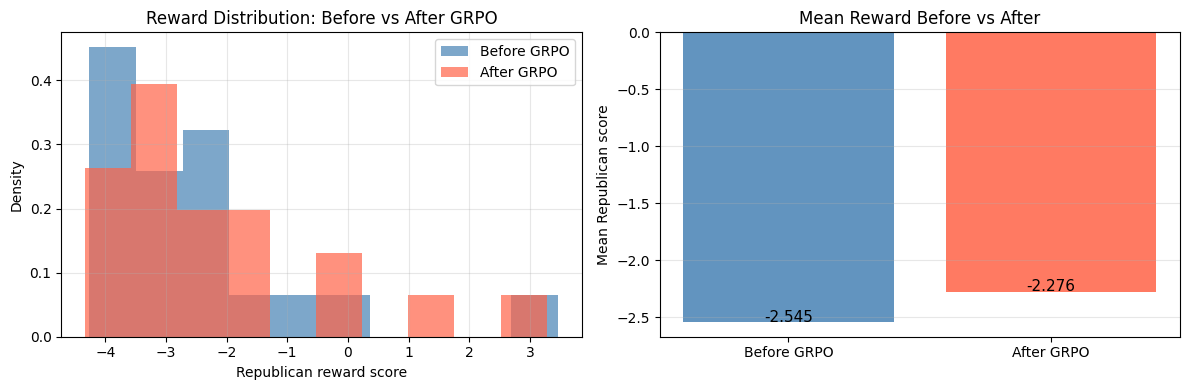

In [16]:
# ── Visualise the reward distribution shift ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rewards_before, bins=10, alpha=0.7, color='steelblue',
             label='Before GRPO', density=True)
axes[0].hist(rewards_after,  bins=10, alpha=0.7, color='tomato',
             label='After GRPO',  density=True)
axes[0].set_xlabel('Republican reward score')
axes[0].set_ylabel('Density')
axes[0].set_title('Reward Distribution: Before vs After GRPO')
axes[0].legend(); axes[0].grid(alpha=0.3)

stats = pd.DataFrame({'Reward': [rewards_before, rewards_after]},
                      index=['Before', 'After']).T
means = [np.mean(rewards_before), np.mean(rewards_after)]
axes[1].bar(['Before GRPO', 'After GRPO'], means,
             color=['steelblue', 'tomato'], alpha=0.85)
axes[1].set_ylabel('Mean Republican score')
axes[1].set_title('Mean Reward Before vs After')
axes[1].grid(alpha=0.3, axis='y')
for i, m in enumerate(means):
    axes[1].text(i, m + 0.005, f'{m:+.3f}', ha='center', fontsize=11)

plt.tight_layout(); plt.show()

In [17]:
# ── Qualitative inspection ────────────────────────────────────────────────
print('Sample completions from Democratic prompts:\n')
for i in range(5):
    print(f'Prompt:  {results.iloc[i]["prompt"][:80]}')
    print(f'Before:  {results.iloc[i]["completion_before"][:100]}')
    print(f'After:   {results.iloc[i]["completion_after"][:100]}')
    print(f'Reward:  {results.iloc[i]["reward_before"]:+.3f} -> {results.iloc[i]["reward_after"]:+.3f}')
    print()

Sample completions from Democratic prompts:

Prompt:  Mr. HOYER. Madam Speaker, Kathy, members of the Fitzpatrick family, and Members
Before:   of Congress. Mr. SANDERS, so we appreciate your interest in following up into duty as the third Hou
After:    of the House

Here's what happened. Kathy Fitzpatrick sits down with Kathy Garfield, Kalis King and
Reward:  -4.274 -> -4.335

Prompt:  Mr. SERRANO. Mr. Speaker, today I pay tribute to Father Lloyd Springer,
Before:   who gave his life to the what we call the Theurgic Prison Bible Project, which was dedicated on Sep
After:    a gentleman who was certainly me for many years. Let us now take care that you can lead us to a loy
Reward:  -2.263 -> -1.952

Prompt:  Mr. CONYERS. Mr. Speaker, I yield myself 2 minutes. Letter to Chairman
Before:   Bowden, May 22, 1995 [Mr. CONYERS: 2 copies] Mr. Chairman, the Committee today gave you BARACK OBAM
After:    Burr.

Mr. Chairman, there is much to say on the matter. I have received briefings coming f

---
## Part 5 — Discussion Questions

Answer the following in the markdown cell below (no code required).

**Question 1 — Reward signal design**

The reward is the Republican class score from DistilBERT. What are the risks of using this as the sole reward signal? Give a concrete example of a completion that would score high on the reward but would be useless or misleading.

**Question 2 — KL penalty**

We set `beta=0.05` in the GRPO config. What happens if you set it to 0? What happens if you set it to 1.0? Which of these connects to the concept of 'reward hacking' from the lab?

**Question 3 — Political framing vs content**

After GRPO training, does the model generate text that is substantively Republican (different policy positions) or does it just learn surface-level stylistic features (different word choices, rhetorical patterns)? How would you design an experiment to distinguish between these two explanations?

Q1 — Reward design: The classifier is a noisy proxy for "sounds Republican," so hard-optimizing it invites reward hacking (Goodhart's law). It rewards lexical cues, not fluency/truth/relevance. Example given: keyword-soup ("tax cuts tax cuts Reagan freedom Second Amendment…") — high reward, useless text.

Q2 — KL penalty: beta=0 removes the leash → the policy drifts far and games the reward model (this is the reward-hacking case). beta=1.0 over-penalizes drift → the model barely changes from base GPT-2. 0.05 is the middle ground.

Q3 — Style vs substance: Argues it's mostly surface style (small model, short training, style-sensitive reward), then gives a 4-part experiment to distinguish them: style/substance probe pairs, a stance-coding minimal-pairs test judged independently, decoupled measurement (DistilBERT vs. an independent substance judge), and a keyword-ablation control.

*Your answers here*

**Q1:** ...

**Q2:** ...

**Q3:** ...